# 05 — Galactic noise

Below about 100 MHz the sky is bright. The Galactic synchrotron background is
the dominant noise source for GRAND, larger than the receiver's own noise, and
it is not constant: as the Earth turns, the Galactic plane rises and sets, and
the noise level follows local sidereal time.

That matters for two reasons. The obvious one is the trigger threshold. The
subtler one is that the noise level is a *calibration signal* — it is the one
input whose amplitude is known independently of the instrument, so comparing
measured to predicted Galactic noise is how the absolute response of a
detection unit gets checked in the field.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from grand import grand_add_path_data
from grand.sim.noise.galaxy import galactic_noise

# The tabulated model is defined on a 1 MHz grid from 30 to 250 MHz.  Asking for
# a different grid interpolates; asking outside the range extrapolates silently,
# so stay inside it.
freqs_mhz = np.arange(30.0, 251.0)

# size_out is the length of the padded time trace the spectrum will eventually be
# transformed back into.  It enters the amplitude normalisation, which is the
# subject of section 6.
SIZE_OUT = 1024

# f_lst is the local sidereal time in hours; seed makes the draw reproducible.
v = galactic_noise(f_lst=18.0, size_out=SIZE_OUT, freqs_mhz=freqs_mhz,
                   nb_ant=4, seed=0)
print("shape (n_ant, 3 arms, n_freq):", v.shape, v.dtype)

shape (n_ant, 3 arms, n_freq): (4, 3, 221) complex128


## 1. The tabulated model

The underlying tables come from LFMap sky brightness temperatures folded
through the antenna response of notebook 03. They are stored per frequency, per
hour of LST, per arm.

The transpose in the next cell is not cosmetic: it is exactly what `galaxy.py`
does internally, and the resulting axis order is what every slice below
assumes.

In [2]:
tab = np.load(grand_add_path_data("noise/Vocmax_30-250MHz_uVperMHz_nec.npy"))
print("as stored :", tab.shape, "  (frequency, LST hour, arm)")

tab = np.transpose(tab, (0, 2, 1))          # what galaxy.py does
print("as used   :", tab.shape, "  (frequency, arm, LST hour)")

# Index 17 is LST 18 h: the code indexes with lst - 1, so hour h is column h-1.
print("one LST slice:", tab[:, :, 17].shape, " -> 221 frequencies x 3 arms at LST 18 h")

as stored : (221, 24, 3)   (frequency, LST hour, arm)
as used   : (221, 3, 24)   (frequency, arm, LST hour)
one LST slice: (221, 3)  -> 221 frequencies x 3 arms at LST 18 h


## 2. Noise against local sidereal time

This is the diurnal cycle. Each arm sees the Galactic plane differently
because each arm points differently — which is exactly the asymmetry notebook
03 measured.

X arm: max at LST 22 h, min at LST  6 h, ratio 1.35
Y arm: max at LST 17 h, min at LST  2 h, ratio 1.45
Z arm: max at LST 15 h, min at LST  6 h, ratio 1.34


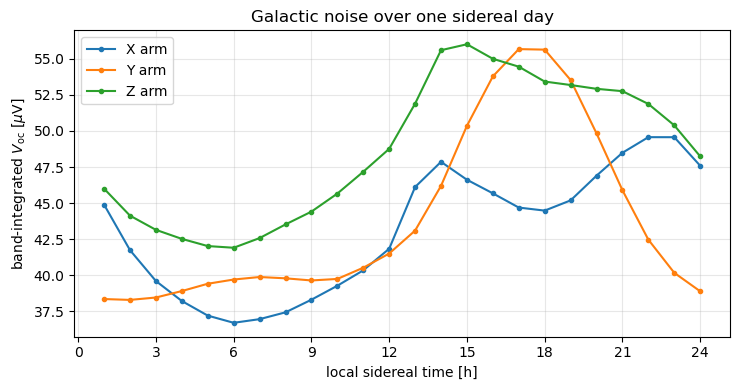

In [3]:
lst_hours = np.arange(1, 25)

fig, ax = plt.subplots(figsize=(7.5, 4))
for i, arm in enumerate('XYZ'):
    # Quadrature sum over frequency: the band-integrated amplitude, since power
    # adds and the table holds amplitudes.
    y = np.sqrt(np.sum(tab[:, i, :] ** 2, axis=0))
    ax.plot(lst_hours, y, marker='o', ms=3, label='%s arm' % arm)

ax.set_xlabel('local sidereal time [h]')
ax.set_ylabel(r'band-integrated $V_{\rm oc}$ [$\mu$V]')
ax.set_title('Galactic noise over one sidereal day')
ax.set_xticks(np.arange(0, 25, 3))
ax.grid(alpha=.3)
ax.legend()
fig.tight_layout()

for i, arm in enumerate('XYZ'):
    y = np.sqrt(np.sum(tab[:, i, :] ** 2, axis=0))
    print("%s arm: max at LST %2d h, min at LST %2d h, ratio %.2f"
          % (arm, lst_hours[y.argmax()], lst_hours[y.argmin()], y.max() / y.min()))

The maxima land at different sidereal hours for different arms — LST 22 h for
X, 17 h for Y, 15 h for Z — because each arm weights the sky differently. The
Z arm is blind at zenith, as notebook 03 measured, so it peaks when the
Galactic plane is low. Fig. 7 of
[arXiv:2408.10926](https://arxiv.org/abs/2408.10926) shows the same behaviour.

The peak-to-trough swing is modest — 35 % to 45 % depending on the arm — but
the trigger rate depends on the threshold steeply enough that it is not a
detail.

## 3. Spectral shape

The sky brightness temperature follows a steep power law, roughly
$T \propto \nu^{-2.5}$. What the antenna *sees* is much flatter than that,
because the effective length of notebook 03 rises with frequency across most
of the band and partly cancels the sky's fall.

LST 18 h, X arm: 3.0 uV/MHz at 30 MHz -> 1.35 uV/MHz at 250 MHz
   falls by a factor 2.2, against ~200 for a bare nu^-2.5 sky


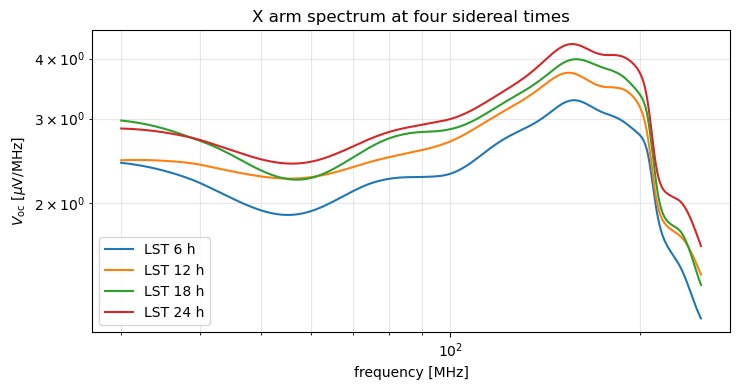

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 4))
for hour in (6, 12, 18, 24):
    ax.loglog(np.arange(30., 251.), tab[:, 0, hour - 1], label='LST %d h' % hour)

ax.set_xlabel('frequency [MHz]')
ax.set_ylabel(r'$V_{\rm oc}$ [$\mu$V/MHz]')
ax.set_title('X arm spectrum at four sidereal times')
ax.grid(alpha=.3, which='both')
ax.legend()
fig.tight_layout()

# Quantify the "much flatter than nu^-2.5" claim: over a factor 8.3 in
# frequency, a nu^-2.5 sky would fall by a factor ~200.
lo, hi = tab[0, 0, 17], tab[-1, 0, 17]
print("LST 18 h, X arm: %.1f uV/MHz at 30 MHz -> %.2f uV/MHz at 250 MHz"
      % (lo, hi))
print("   falls by a factor %.1f, against ~%.0f for a bare nu^-2.5 sky"
      % (lo / hi, (250 / 30.) ** 2.5))

## 4. One realisation

`galactic_noise` returns a *random draw*, not the table: a complex spectrum per
antenna and arm, with amplitude set by the table and phase randomised. Fixing
`seed` makes it reproducible.

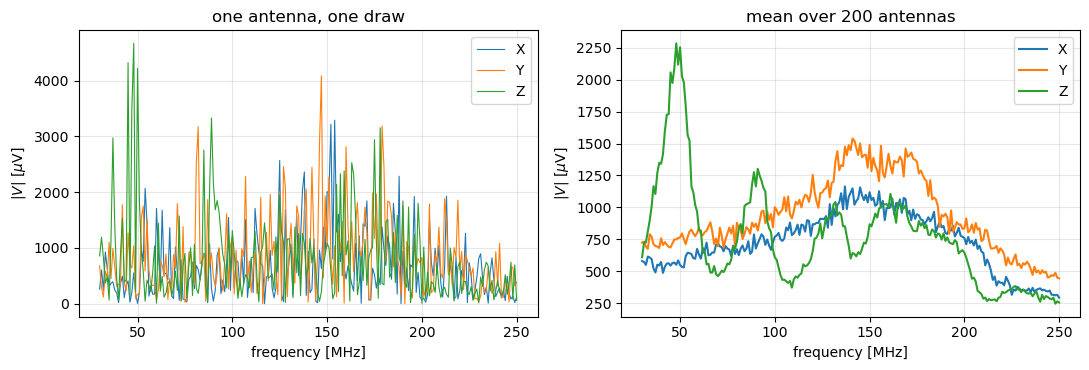

In [5]:
v = galactic_noise(18.0, SIZE_OUT, freqs_mhz, nb_ant=200, seed=1)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for i, arm in enumerate('XYZ'):
    ax[0].plot(freqs_mhz, np.abs(v[0, i]), lw=.8, label=arm)     # one antenna
    ax[1].plot(freqs_mhz, np.mean(np.abs(v[:, i]), axis=0), label=arm)  # averaged

ax[0].set_title('one antenna, one draw')
ax[1].set_title('mean over 200 antennas')
for a in ax:
    a.set_xlabel('frequency [MHz]')
    a.set_ylabel(r'$|V|$ [$\mu$V]')
    a.grid(alpha=.3)
    a.legend()
fig.tight_layout()

Averaging over antennas recovers the smooth tabulated shape, as it must.
Neighbouring detection units get **independent** draws: spatial coherence of
the Galactic background is not modelled, on the argument that the array is
sparse compared with the coherence scale.

## 5. Reproducibility, and one thing to watch

Two calls with the same seed agree exactly; without a seed they do not. The
tests depend on this.

In [6]:
a = galactic_noise(18.0, SIZE_OUT, freqs_mhz, nb_ant=2, seed=42)
b = galactic_noise(18.0, SIZE_OUT, freqs_mhz, nb_ant=2, seed=42)
c = galactic_noise(18.0, SIZE_OUT, freqs_mhz, nb_ant=2)          # no seed
print("same seed identical :", np.array_equal(a, b))
print("no seed identical   :", np.array_equal(a, c))

# f_lst is truncated with int(), not interpolated, so the LST axis has 1 h
# resolution.  Same seed and same hour-bin therefore give the same draw.
d = galactic_noise(18.0, SIZE_OUT, freqs_mhz, nb_ant=2, seed=7)
e = galactic_noise(18.9, SIZE_OUT, freqs_mhz, nb_ant=2, seed=7)
print("LST 18.0 h and 18.9 h identical:", np.array_equal(d, e))

same seed identical : True
no seed identical   : False
LST 18.0 h and 18.9 h identical: True


The last line is a real limitation: `f_lst` is truncated with `int()`, so the
LST axis has 1-hour resolution and 18.9 h is silently treated as 18 h. For a
noise level that varies by 35–45 % over a day, hour-quantisation is a
few-percent effect — tolerable, but it should be interpolation, and the `TODO`
in the source says so.

## 6. The normalisation, and how to check it yourself

The amplitude of the returned spectrum is scaled by a constant involving
`size_out`, and there is an open PR (#153) that changes it from `size_out/2`
to `size_out/sqrt(2)` — a factor of 1.41 on every simulated noise voltage, and
therefore on every trigger threshold downstream.

Parseval's theorem decides it, provided the comparison is made against the
table the simulation actually used. **That last clause matters**: the three
`du_type` values read different files, and those files differ in absolute
level by up to a factor of two, so comparing across them measures the model
difference rather than the normalisation.

In [7]:
from scipy import fft

freqs = np.arange(30., 251.)
N_ANT, N = 600, 2048

for du, path in [('GP300_nec', "noise/Vocmax_30-250MHz_uVperMHz_nec.npy"),
                 ('GP300_mat', "noise/Vocmax_30-250MHz_uVperMHz_mat.npy")]:
    # The reference: what the table says the band RMS should be at LST 18 h.
    ref_tab = np.transpose(np.load(grand_add_path_data(path)), (0, 2, 1))
    ref = np.sqrt(np.sum(ref_tab[:, :, 17] ** 2, axis=0))

    # The simulation, transformed back to the time domain.  The 221 in-band bins
    # are placed at indices 30..250 of a length-N/2+1 one-sided spectrum, which
    # is what efield2voltage effectively does; irfft then gives a real trace.
    v = galactic_noise(18.0, N, freqs, nb_ant=N_ANT, seed=0, du_type=du)
    full = np.zeros((N_ANT, 3, N // 2 + 1), dtype=complex)
    full[:, :, 30:251] = v
    sim = np.std(fft.irfft(full, n=N, axis=-1), axis=-1).mean(axis=0)

    print("%-10s simulated/tabulated = %s   (1/sqrt2 = %.4f)"
          % (du, np.round(sim / ref, 4), 1 / np.sqrt(2)))

GP300_nec  simulated/tabulated = [0.703  0.7066 0.7084]   (1/sqrt2 = 0.7071)


GP300_mat  simulated/tabulated = [0.703  0.7066 0.7084]   (1/sqrt2 = 0.7071)


The ratio is $1/\sqrt{2}$ — to about 0.3 %, for every arm, and (you can check)
independently of `size_out` and of the number of antennas. That is exactly the
relation between the RMS and the peak of a sinusoid.

So the code produces an RMS equal to the tabulated value divided by $\sqrt2$,
and the whole decision reduces to one definitional question:

> **Is `Vocmax_30-250MHz_uVperMHz` an RMS voltage spectral density, or a
> maximum?**

| if the table is a… | then the right constant is |
|---|---|
| **maximum** | `size_out/2` — the current code is right, and PR #153 would break it |
| **RMS** | `size_out/sqrt(2)` — PR #153 is right |

The filename says *max*. Nothing else in the repository states which is meant,
and the question belongs to whoever produced the tables — it is not something
the code can answer.

Until it is answered, quote the version of `grand.sim.noise.galaxy` that
produced any absolute noise level; `TRun.software_version` exists for that.
Relative statements — spectral shape, LST dependence, ratios between arms —
are unaffected, because the disputed factor is a single constant applied to
every model alike.

Pinned by `tests/sim/test_galactic_noise_normalisation.py` and written up in
`docs/dev/issues/galactic-noise-normalisation.md`.

## 7. A trap: `du_type` changes the answer by a factor of two

The three antenna models are not three normalisations of one number. Two of
them are the *same file*, and the default reads neither.

In [8]:
import hashlib

# If two selectors read byte-identical files they cannot be different models.
for kind in ('Vocmax_30-250MHz_uVperMHz', 'Pocmax_30-250_Watt_per_MHz'):
    h = {}
    for variant in ('hfss', 'nec', 'mat'):
        with open(grand_add_path_data("noise/%s_%s.npy" % (kind, variant)), 'rb') as fh:
            h[variant] = hashlib.sha256(fh.read()).hexdigest()[:12]
    print("%-30s nec=%s mat=%s  identical: %s"
          % (kind, h['nec'], h['mat'], h['nec'] == h['mat']))

print()
print("band-integrated V_oc at LST 18 h, per arm:")
for variant in ('hfss', 'nec', 'mat'):
    t = np.transpose(np.load(grand_add_path_data(
        "noise/Vocmax_30-250MHz_uVperMHz_%s.npy" % variant)), (0, 2, 1))
    print("   %-5s %s uV" % (variant,
                             np.round(np.sqrt(np.sum(t[:, :, 17] ** 2, axis=0)), 1)))

Vocmax_30-250MHz_uVperMHz      nec=1007a7f56b70 mat=1007a7f56b70  identical: True
Pocmax_30-250_Watt_per_MHz     nec=94fc057deca2 mat=94fc057deca2  identical: True

band-integrated V_oc at LST 18 h, per arm:
   hfss  [59.6 75.5 66.9] uV
   nec   [44.5 55.6 53.4] uV
   mat   [44.5 55.6 53.4] uV


`_nec` and `_mat` are byte-identical, so `du_type='GP300_nec'` and
`du_type='GP300_mat'` give the same numbers despite the docstring calling them
different antenna simulations. And the default, `du_type='GP300'`, reads
*neither* — it recomputes the voltage from `PG_ALL_jifen.mat` as
$V_{\rm oc}^2 = 4PR_{\rm ant}$, landing about 40 % below the `nec` tables and
a factor 2.1 below the `hfss` tables, which no `du_type` reaches at all.

**A Galactic noise level quoted without its `du_type` is ambiguous by a factor
of two.** This is separate from the $\sqrt2$ question above; see the
[known issues page](https://grand-mother.github.io/grand-docs/known_issues.html).

## Where next

- [03 — The antenna response](03_antenna_response.ipynb) — the effective length these tables were folded through
- [04 — The RF chain](04_rf_chain.ipynb) — what the noise passes through next
- [06 — From electric field to ADC counts](06_efield_to_adc.ipynb)